In [ ]:
!pip install git+https://github.com/Starlitnightly/dynamo-release.git

In [2]:
import dynamo as dyn
dyn.configuration.set_figure_params('dynamo', background='white')
print(f'dynamo version: {dyn.__version__}')

dynamo version: 1.4.2rc1


In [3]:
dyn.pl.style()



 ███                               ████████        
█████   █████    █████    █████    ███   █████      
   ██████   ██████   ██████   ████████      ████ 
  ___                           ████            ███
 |   \ _  _ _ _  __ _ _ __  ___                 ███
 | |) | || | ' \/ _` | '  \/ _ \█████           ███ 
 |___/ \_, |_||_\__,_|_|_|_\___/█████       ████  
       |__/                        ███   █████     
Tutorial: https://dynamo-release.readthedocs.io/       
                                     █████      



In [4]:
adata=dyn.sample_data.bone_marrow()
adata

|-----> Downloading data to ./data/bone_marrow.h5ad
|-----> File ./data/bone_marrow.h5ad already exists.


AnnData object with n_obs × n_vars = 5780 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential'
    var: 'palantir'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs'
    layers: 'spliced', 'unspliced'

In [5]:
adata=adata[adata.obs['clusters']!='CLP']

In [6]:
adata.layers['counts']=adata.X.copy()

In [7]:
preprocessor = dyn.pp.Preprocessor(cell_cycle_score_enable=True,
                                  gene_append_list=['GATA1','SPI1'])
preprocessor.preprocess_adata(adata, recipe='monocle')

|-----> Running monocle preprocessing pipeline...
|-----------> filtered out 0 outlier cells
|-----------> filtered out 20923 outlier genes
|-----> appended 2 extra genes as required...
|-----> PCA dimension reduction
|-----> <insert> X_pca to obsm in AnnData Object.
|-----> computing cell phase...
|-----> [Cell Phase Estimation] completed [130.1781s]
|-----> [Cell Cycle Scores Estimation] completed [0.7054s]
|-----> [Preprocessor-monocle] completed [30.6346s]


In [8]:
#dyn.tl.dynamics(adata, model='stochastic', cores=3) 
# or dyn.tl.dynamics(adata, model='deterministic')
dyn.tl.dynamics(adata, #filter_gene_mode='basic',
                model='auto', est_method='auto',
                #sanity_check=True,
               cores=12)


|-----> dynamics_del_2nd_moments_key is None. Using default value from DynamoAdataConfig: dynamics_del_2nd_moments_key=False
|-----------> removing existing M layers:[]...
|-----------> making adata smooth...
|-----> calculating first/second moments...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----? layer X_counts is not in any of the (['X_spliced', 'X_unspliced'], ['X_new', 'X_total'], ['X_uu', 'X_ul', 'X_su', 'X_sl']) groups, skipping...
|-----> [moments calculation] completed [45.2469s]


AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'palantir', 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'log_cv', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'cell_cycle_scores'
    varm: 'vel_params'
    layers: 'spliced', 'unspliced', 'counts', 'X_unspliced', 'X_counts', 'X_spliced', 'M_u', 'M_uu', 'M_s', 'M_us', 'M_ss',

|-----> retrieve data for non-linear dimension reduction...
|-----> [UMAP] using X_pca with n_pca_components = 30
|-----> <insert> X_umap to obsm in AnnData Object.
|-----> [UMAP] completed [15.4485s]
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


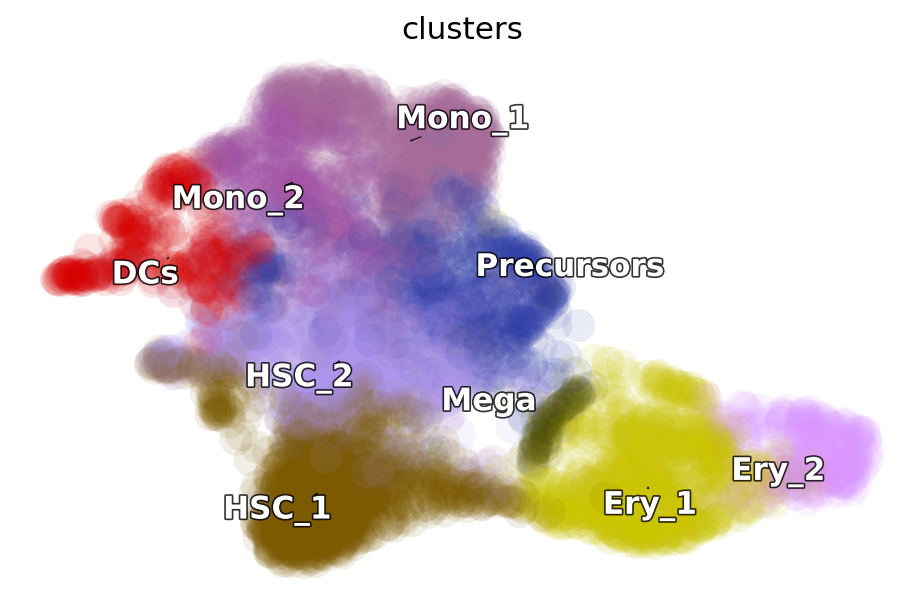

In [9]:
dyn.tl.reduceDimension(adata)
dyn.pl.umap(adata, color='clusters',
           save_show_or_return='show',
            adjust_legend=True)

In [10]:
dyn.tl.cell_velocities(adata, method='pearson', 
                       other_kernels_dict={'transform': 'sqrt'}
                      )


|-----> incomplete neighbor graph info detected: connectivities and distances do not exist in adata.obsp, indices not in adata.uns.neighbors.
|-----> Neighbor graph is broken, recomputing....
|-----> Start computing neighbor graph...
|-----------> X_data is None, fetching or recomputing...
|-----> fetching X data from layer:None, basis:pca
|-----> method arg is None, choosing methods automatically...
|-----------> method pynn selected
|-----> [calculating transition matrix via pearson kernel with sqrt transform.] in progress: 100.0000%|-----> [calculating transition matrix via pearson kernel with sqrt transform.] completed [7.1720s]
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [1.2462s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase'
    var: 'palantir', 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'log_cv', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_umap'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'cell_cycle_scores', 'X_umap', 'velocity_umap'
    varm: 'vel_params'
    layers: 'spliced', 'uns

|-----> X shape: (5292, 2) V shape: (5292, 2)
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


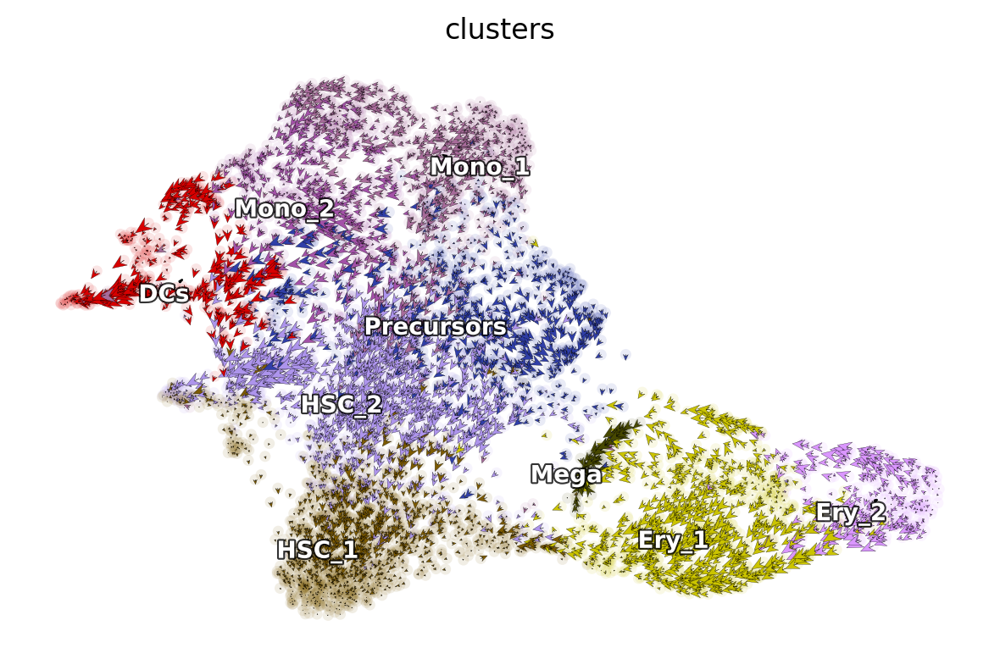

In [11]:
dyn.pl.cell_wise_vectors(adata, color=['clusters'], basis='umap', 
                         show_legend='on data', quiver_length=6, 
                         quiver_size=6, pointsize=0.1, 
                         s_kwargs_dict={'adjust_legend':True},
                         show_arrowed_spines=False)


In [12]:
dyn.tl.cell_wise_confidence(adata,method='cosine')

calculating cosine based cell wise confidence: 100%|██████████| 5292/5292 [01:23<00:00, 63.67it/s] 


AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase', 'cosine_velocity_confidence'
    var: 'palantir', 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'log_cv', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_umap'
    obsm: 'MAGIC_imputed_data', 'X_tsne', 'palantir_branch_probs', 'X_pca', 'cell_cycle_scores', 'X_umap', 'velocity_umap'
    varm: 'vel_param

In [13]:
dyn.tl.confident_cell_velocities(adata, group='clusters',
                                 lineage_dict={'HSC_1': ['Ery_2','Mono_2']},
                                )

calculating gene velocity vectors confidence based on phase portrait location with priors of progenitor/mature cell types: 2001it [01:15, 26.35it/s]


|-----> [calculating transition matrix via pearson kernel with sqrt transform.] in progress: 100.0000%|-----> [calculating transition matrix via pearson kernel with sqrt transform.] completed [3.8841s]
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [1.2039s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase', 'cosine_velocity_confidence'
    var: 'palantir', 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'log_cv', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition', 'avg_prog_confidence', 'avg_mature_confidence', 'avg_confidence', 'confident_genes'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_umap', 'gene_wise_confidence'
    obsm: 'MAGIC_imputed_data', 'X

|-----> X shape: (5292, 2) V shape: (5292, 2)
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


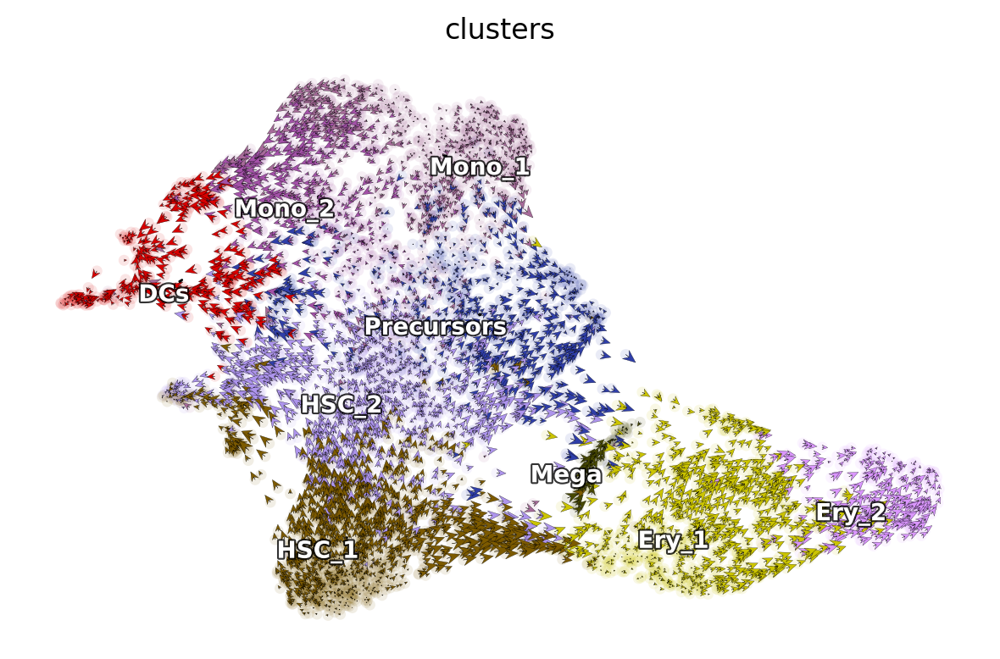

In [14]:
dyn.pl.cell_wise_vectors(adata, color=['clusters'], basis='umap', 
                         show_legend='on data', quiver_length=6, 
                         quiver_size=6, pointsize=0.1, 
                         s_kwargs_dict={'adjust_legend':True},
                         show_arrowed_spines=False)


|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


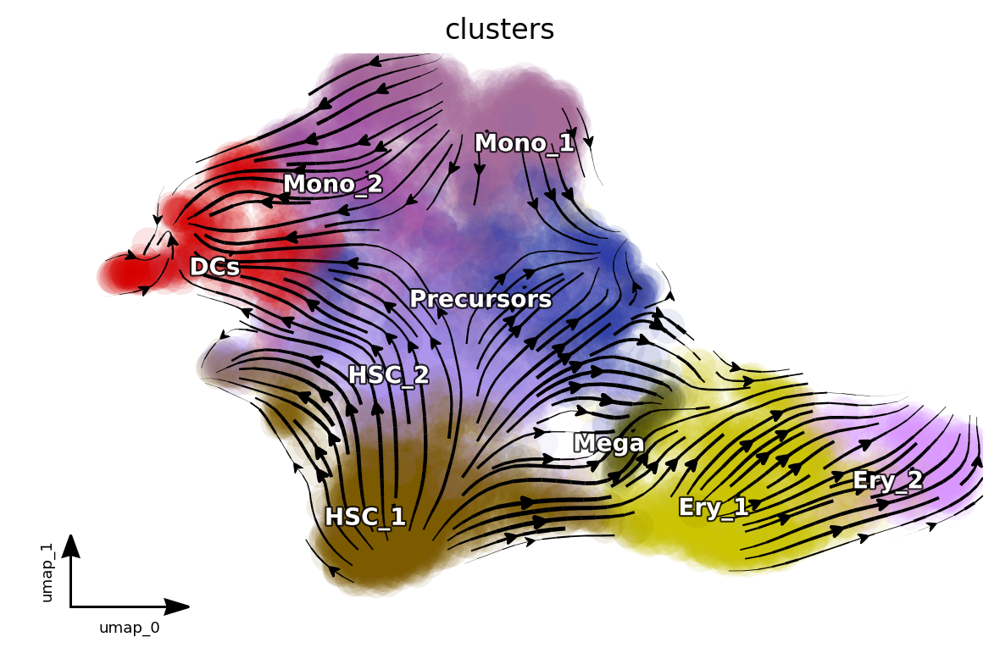

In [15]:
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap


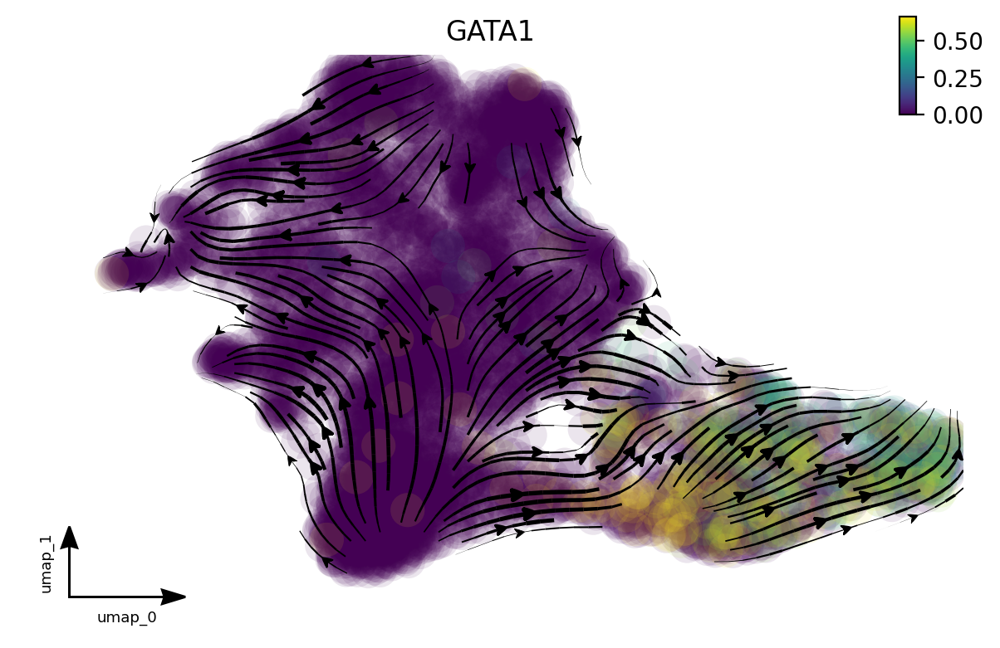

In [16]:
dyn.pl.streamline_plot(adata, color=['GATA1'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap


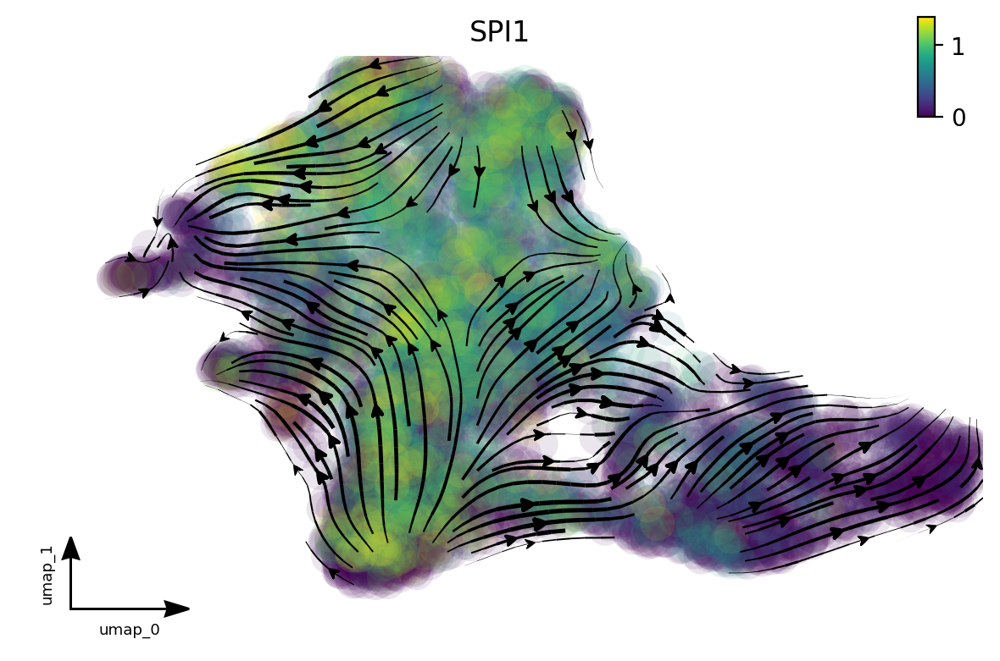

In [17]:
dyn.pl.streamline_plot(adata, color=['SPI1'], 
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True},
                       show_arrowed_spines=True)

In [18]:
dyn.tl.cell_velocities(adata, basis="pca")

Using existing pearson_transition_matrix found in .obsp.
|-----> [projecting velocity vector to low dimensional embedding] in progress: 100.0000%|-----> [projecting velocity vector to low dimensional embedding] completed [1.5114s]
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected


AnnData object with n_obs × n_vars = 5292 × 27876
    obs: 'clusters', 'palantir_pseudotime', 'palantir_diff_potential', 'nGenes', 'nCounts', 'pMito', 'pass_basic_filter', 'unspliced_Size_Factor', 'initial_unspliced_cell_size', 'Size_Factor', 'initial_cell_size', 'spliced_Size_Factor', 'initial_spliced_cell_size', 'counts_Size_Factor', 'initial_counts_cell_size', 'ntr', 'cell_cycle_phase', 'cosine_velocity_confidence'
    var: 'palantir', 'nCells', 'nCounts', 'pass_basic_filter', 'log_m', 'log_cv', 'score', 'frac', 'use_for_pca', 'ntr', 'use_for_dynamics', 'use_for_transition', 'avg_prog_confidence', 'avg_mature_confidence', 'avg_confidence', 'confident_genes'
    uns: 'clusters_colors', 'palantir_branch_probs_cell_types', 'pp', 'velocyto_SVR', 'feature_selection', 'PCs', 'explained_variance_ratio_', 'pca_mean', 'cell_phase_order', 'cell_phase_genes', 'vel_params_names', 'dynamics', 'neighbors', 'umap_fit', 'grid_velocity_umap', 'gene_wise_confidence', 'grid_velocity_pca'
    obsm: 'MA

In [19]:
# you can set `verbose = 1/2/3` to obtain different levels of running information of vector field reconstruction
dyn.vf.VectorField(adata, basis='pca')
dyn.vf.VectorField(adata, basis='umap', M=100, pot_curl_div=True) 

|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: PCA. 
        Vector field will be learned in the PCA space.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method ball_tree selected
|-----> [SparseVFC] completed [4.9730s]
|-----> [VectorField] completed [5.1865s]
|-----> VectorField reconstruction begins...
|-----> Retrieve X and V based on basis: UMAP. 
        Vector field will be learned in the UMAP space.
|-----> Generating high dimensional grids and convert into a row matrix.
|-----> Learning vector field with method: sparsevfc.
|-----> [SparseVFC] begins...
|-----> Sampling control points based on data velocity magnitude...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----> [SparseVFC] completed [6.6035s]
|--

Calculating 2-D curl: 100%|██████████| 5292/5292 [00:00<00:00, 25975.39it/s]

|-----> Computing divergence...



Calculating divergence: 100%|██████████| 6/6 [00:00<00:00, 34.34it/s]


|-----> [VectorField] completed [47.7554s]


|-----> Vector field for umap is but its topography is not mapped. Mapping topography now ...
|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


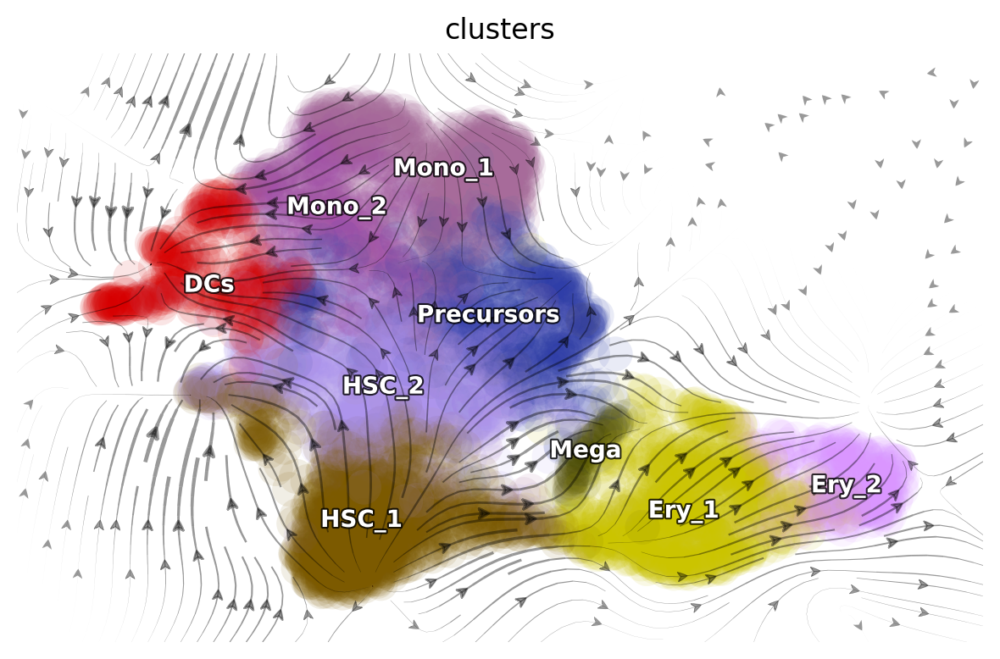

In [20]:
dyn.pl.topography(adata, color=['clusters'], basis='umap', background='white',
                  streamline_color='black', #color_key = pancreas_cluster_cmap,
                  show_legend='on data', terms=("streamline"))


|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


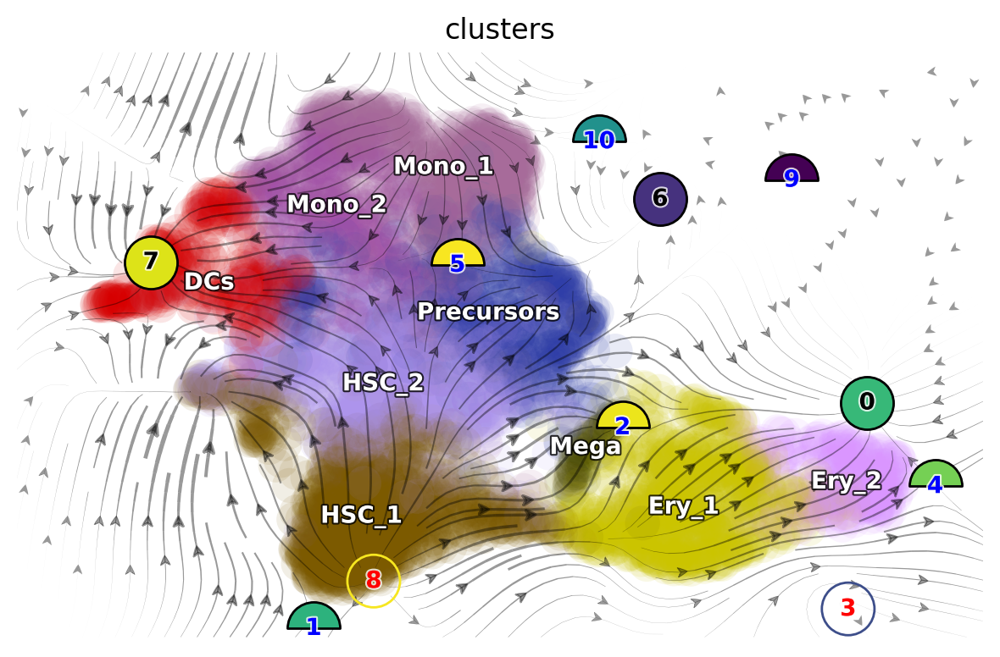

In [21]:
dyn.pl.topography(
    adata,
    markersize=500,
    basis="umap",
    fps_basis="umap",
    #color_key = pancreas_cluster_cmap,
    color=["clusters"],
    show_legend='on data',
    save_show_or_return='show'
)

Transforming subset Jacobian: 100%|██████████| 5292/5292 [00:00<00:00, 98120.61it/s]


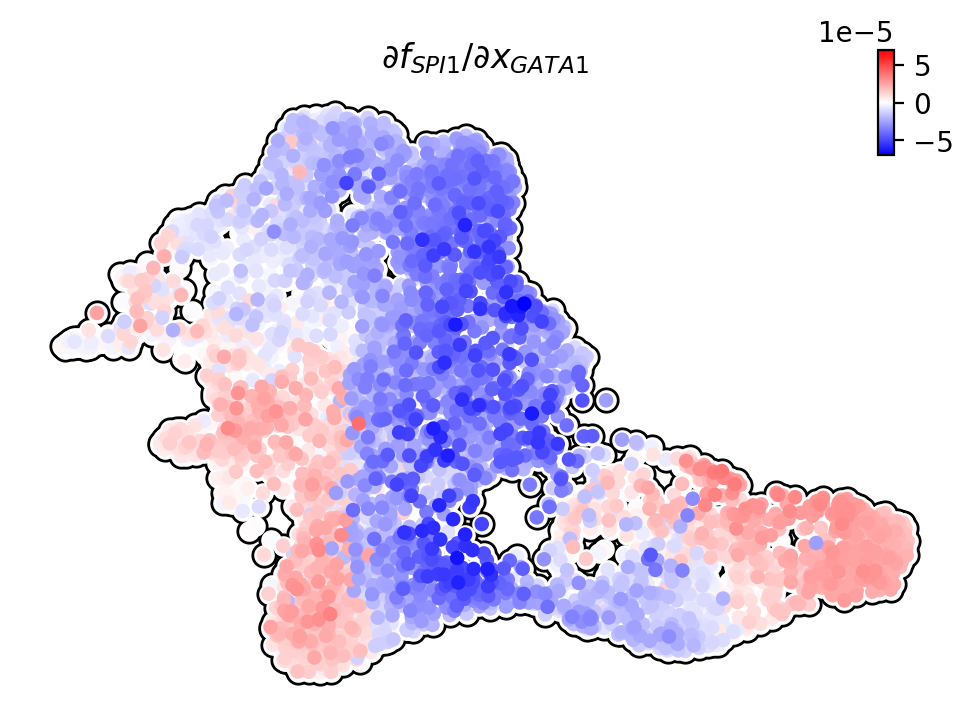

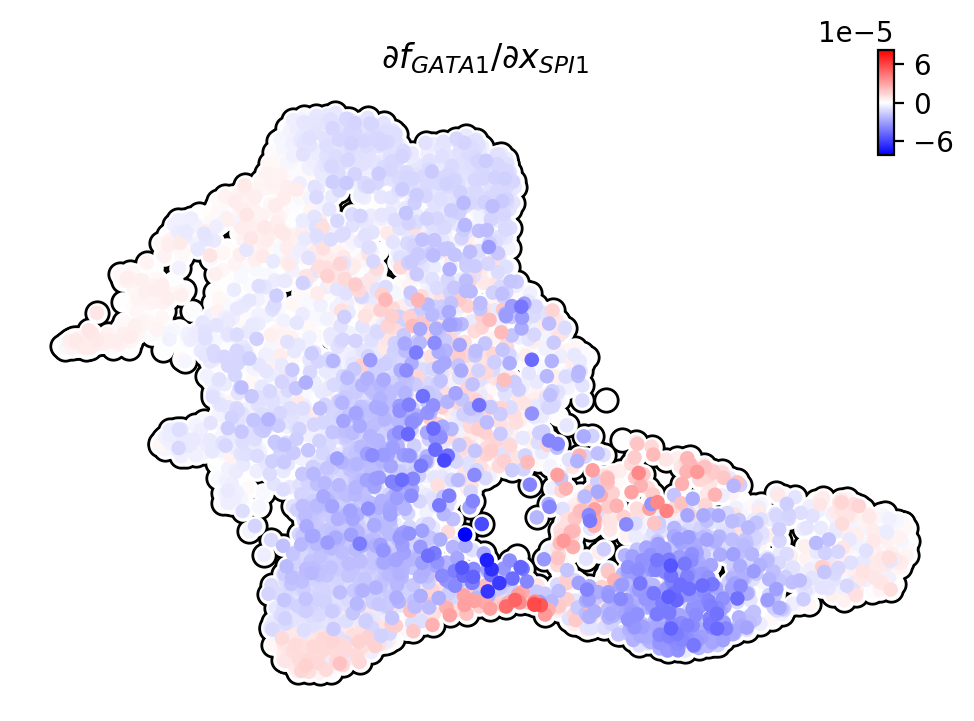

In [22]:
dyn.vf.jacobian(adata, regulators=['GATA1','SPI1'])

dyn.pl.jacobian(
    adata,
    basis="umap",
    regulators=['GATA1'],
    effectors=['SPI1'],
    alpha=1,
)

dyn.pl.jacobian(
    adata,
    basis="umap",
    regulators=['SPI1'],
    effectors=['GATA1'],
    alpha=1,
)

Transforming subset Jacobian: 100%|██████████| 5292/5292 [00:00<00:00, 105377.82it/s]


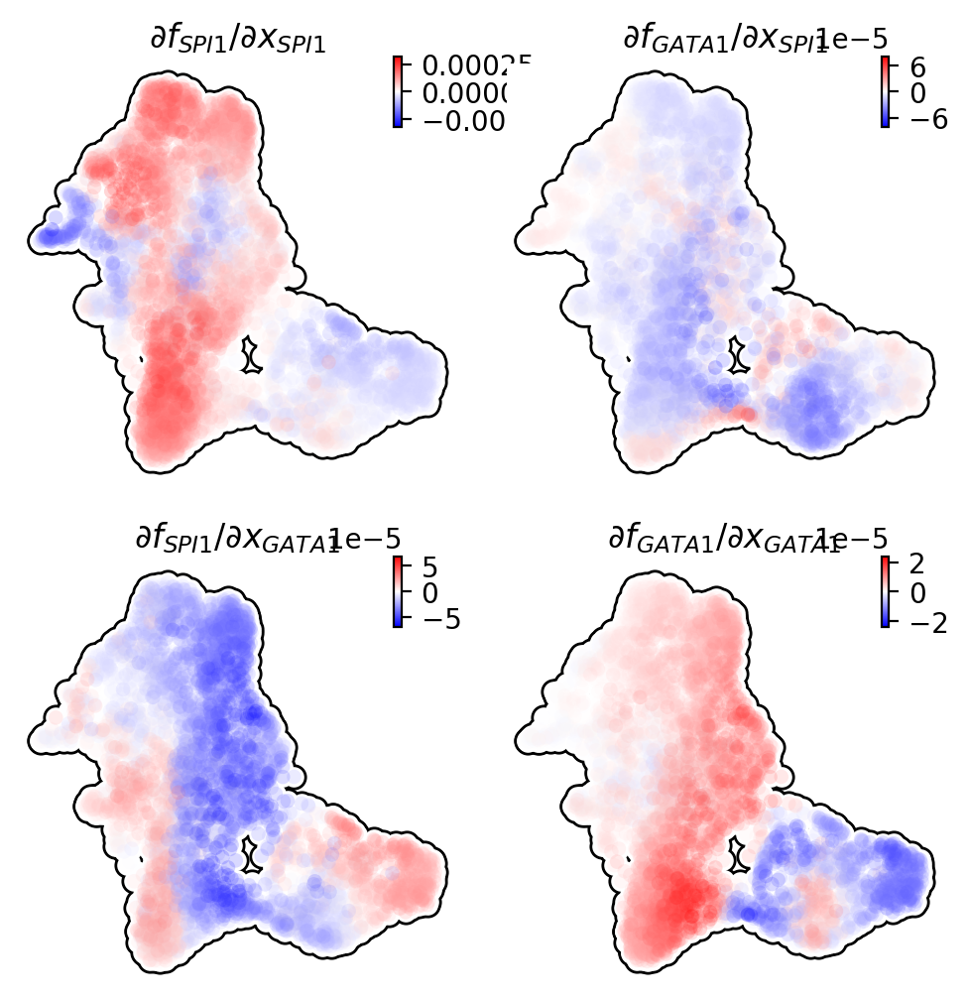

In [23]:
dyn.vf.jacobian(adata,
                regulators = ["SPI1", "GATA1"])
dyn.pl.jacobian(adata, figsize=(3,3),
                regulators = ["SPI1", "GATA1"])

Transforming subset Jacobian: 100%|██████████| 5292/5292 [00:00<00:00, 107444.22it/s]


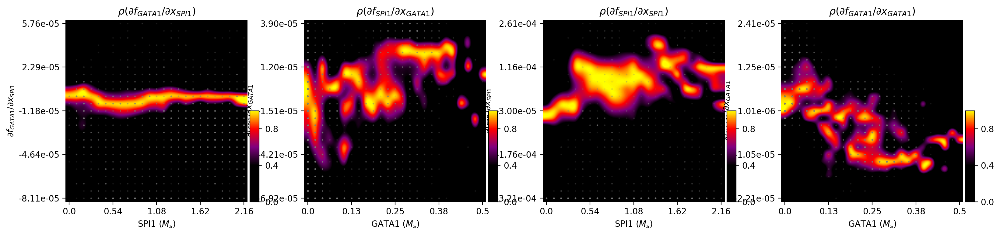

In [24]:
import numpy as np
dyn.vf.jacobian(adata, regulators=["SPI1", "GATA1"], 
                effectors=["SPI1", "GATA1"])
#dyn.pl.style()
dyn.pl.response(
    adata,
    np.array([["SPI1", "GATA1"], ["GATA1", "SPI1"], 
              ["SPI1", "SPI1"], ["GATA1", "GATA1"]]),
    ykey="jacobian",
    log=False,
    drop_zero_cells=True,
    grid_num=25,
    figsize=(4, 4),
    save_show_or_return="show"
)

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


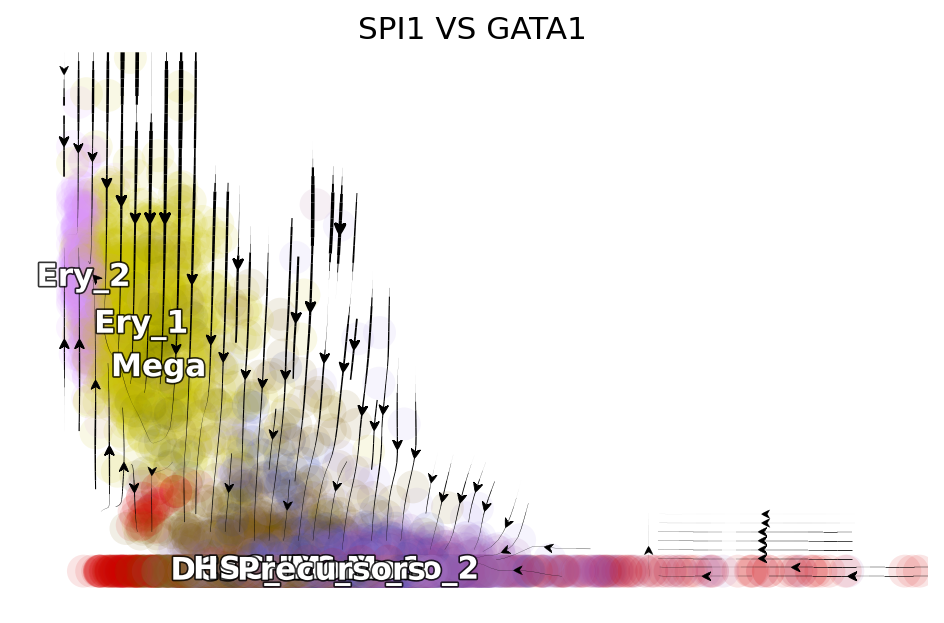

In [25]:
%matplotlib inline
dyn.pl.style()
dyn.pl.streamline_plot(
    adata,
    color="clusters",
    x="SPI1",
    y="GATA1",
    layer="M_s",
    ekey="M_s",
    #vkey="velocity_alpha_minus_gamma_s",
)

In [34]:
color_dict={'HSC_1': '#fcd4e4',
 'HSC_2': '#f494a4',
 'Ery_1': '#cc141c',
 'Mono_1': '#043464',
 'Precursors': '#acd4ec',
 'Mono_2': '#3474ac',
 'DCs': '#143c3c',
 'Ery_2': '#8c1c24',
 'Mega': '#fcc43c'}

|-----> method arg is None, choosing methods automatically...
|-----------> method kd_tree selected
|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'HSC:CellType[Ms/Mu]')

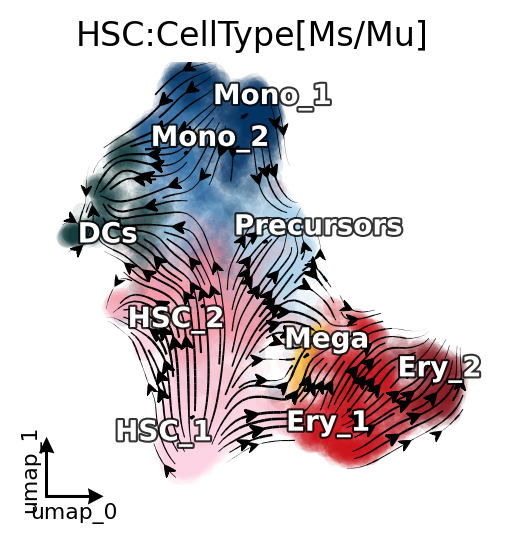

In [36]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.streamline_plot(adata, color=['clusters'], 
                       color_key=color_dict,
                       title='HSC:CellType',
                       basis='umap', show_legend='on data', 
                       s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                       linewidth=0.5,
                       show_arrowed_spines=True,
                      save_show_or_return='return',ax=ax)
plt.title('HSC:CellType[Ms/Mu]',fontsize=12)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Velo.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap
|-----------> skip filtering clusters by stack threshold when stacking color because it is not a numeric type


Text(0.5, 1.0, 'HSC:Topography[Ms/Mu]')

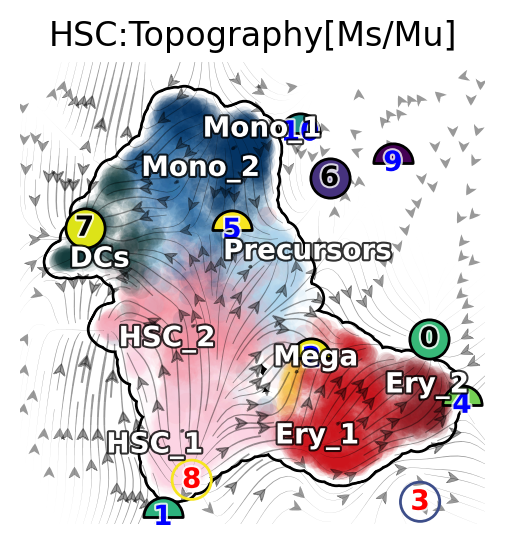

In [37]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'clusters'], 
                  color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
plt.title('HSC:Topography[Ms/Mu]',fontsize=12)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Topography.png', dpi=300, bbox_inches='tight')

|-----------> plotting with basis key=X_umap


Text(0.5, 1.0, 'HSC:Potential[Ms/Mu]')

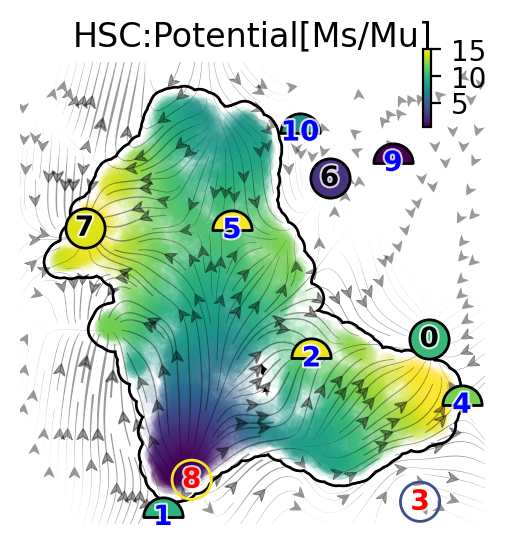

In [38]:
%matplotlib inline
import matplotlib.pyplot as plt
fig,ax=plt.subplots(1,1,figsize = (3,3))
dyn.pl.topography(adata, basis='umap', background='white', 
                  color=[ 'umap_ddhodge_potential'], 
                  #color_key=color_dict,
                  streamline_color='black',
                  s_kwargs_dict={'adjust_legend':True,
                                     's':50},
                  linewidth=0.5,
                  show_legend='on data', frontier=True,
                 save_show_or_return='return',ax=ax)
ax.set_title('HSC:Potential[Ms/Mu]',fontsize=12)
#fig.savefig(f'figures/fig3/Ms_Mu_HSC_Potential.png', dpi=300, bbox_inches='tight')